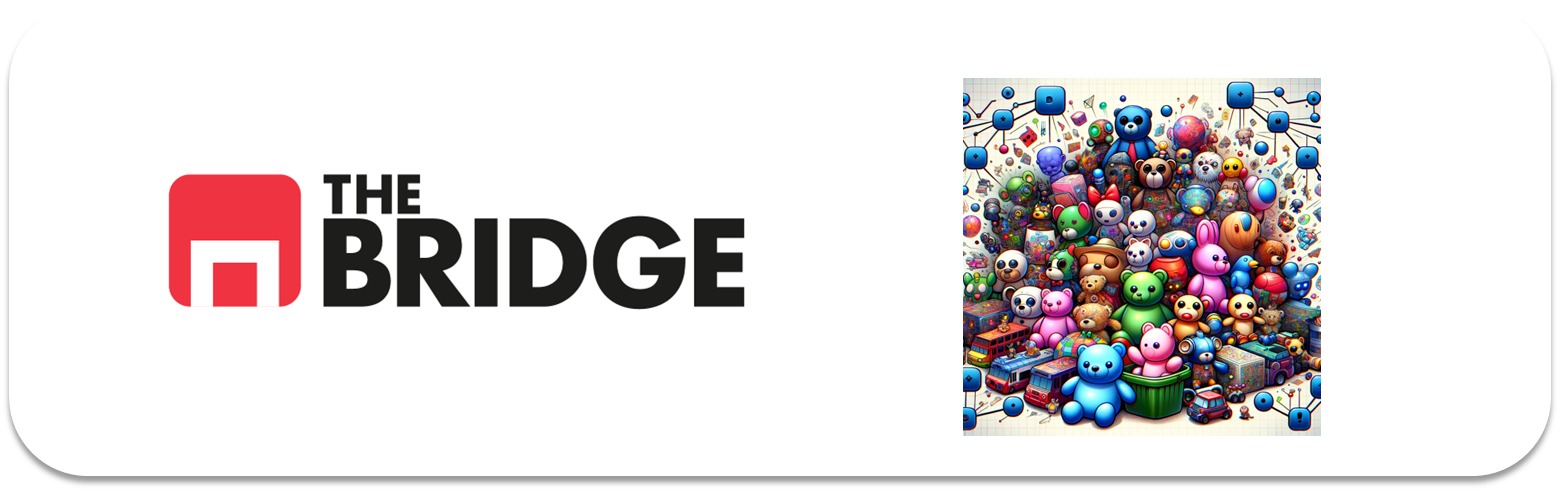

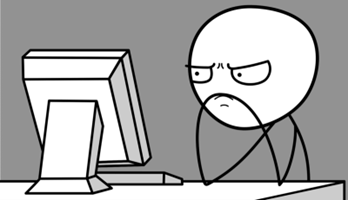

Para ejercitarte y afianzar lo aprendido sobre **K-Means**, completa los siguientes ejercicios. Recuerda que necesitarás datos que están en el directorio data que acompaña al notebook (búscalo en el repositorio de ejercicios)
  
La solución a los mismos las tienes ya, intenta no mirarlos de primeras pero no dejes de hacerlo cuando hayas terminado por si te pudieran aportar.

### Ejercicio 0

Importa los paquetes y módulos que necesites a lo largo del notebook

In [1]:
# Common imports
import numpy as np
import os
import pandas as pd

# to make this notebook's output stable across runs
np.random.seed(42)

# To plot pretty figures
%matplotlib inline
import matplotlib as mpl
import matplotlib.pyplot as plt
mpl.rc('axes', labelsize=14)
mpl.rc('xtick', labelsize=12)
mpl.rc('ytick', labelsize=12)

# Ignore useless warnings (see SciPy issue #5998)
import warnings
warnings.filterwarnings(action="ignore", message="^internal gelsd")

### Entendiendo el problema de negocio

En este notebook vamos a hacer un análisis de datos tirando de clusterizaciones para evaluar si existen grupos en nuestros productos, en este caso medicamentos, y posteriormente poder etiquetarlos. Poseemos información como rating, efectividad, efectos secundarios, entre otros.

### Ejercicio 1

Importa los datos, "./data/drugLibTrain_raw.tsv", que contiene un dataset con diferentes fármacos, sus efectos y ratings de los clientes de dichos fármacos. Realiza una inspección preliminar y quita las columnas que consideres innecesarias.

In [2]:
df = pd.read_csv("./data/drugLibTrain_raw.tsv", sep="\t")

In [3]:
df.head()

,Unnamed: 0,urlDrugName,rating,effectiveness,sideEffects,condition,benefitsReview,sideEffectsReview,commentsReview
0,2202,enalapril,4,Highly Effective,Mild Side Effects,management of congestive heart failure,slowed the progression of left ventricular dys...,"cough, hypotension , proteinuria, impotence , ...","monitor blood pressure , weight and asses for ..."
1,3117,ortho-tri-cyclen,1,Highly Effective,Severe Side Effects,birth prevention,Although this type of birth control has more c...,"Heavy Cycle, Cramps, Hot Flashes, Fatigue, Lon...","I Hate This Birth Control, I Would Not Suggest..."
2,1146,ponstel,10,Highly Effective,No Side Effects,menstrual cramps,I was used to having cramps so badly that they...,Heavier bleeding and clotting than normal.,I took 2 pills at the onset of my menstrual cr...
3,3947,prilosec,3,Marginally Effective,Mild Side Effects,acid reflux,The acid reflux went away for a few months aft...,"Constipation, dry mouth and some mild dizzines...",I was given Prilosec prescription at a dose of...
4,1951,lyrica,2,Marginally Effective,Severe Side Effects,fibromyalgia,I think that the Lyrica was starting to help w...,I felt extremely drugged and dopey. Could not...,See above


In [4]:
df.shape

(3107, 9)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3107 entries, 0 to 3106
Data columns (total 9 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   Unnamed: 0         3107 non-null   int64 
 1   urlDrugName        3107 non-null   object
 2   rating             3107 non-null   int64 
 3   effectiveness      3107 non-null   object
 4   sideEffects        3107 non-null   object
 5   condition          3106 non-null   object
 6   benefitsReview     3089 non-null   object
 7   sideEffectsReview  3032 non-null   object
 8   commentsReview     3095 non-null   object
dtypes: int64(2), object(7)
memory usage: 218.6+ KB


In [6]:
df.describe()

,Unnamed: 0,rating
count,3107.000000,3107.000000
mean,2080.607016,7.006115
std,1187.998828,2.937582
min,0.000000,1.000000
25%,1062.500000,5.000000
50%,2092.000000,8.000000
75%,3092.500000,9.000000
max,4161.000000,10.000000


### Ejercicio 2: MiniEDA

Como es un problema no supervisado (vamos a intentar agrupar los medicamentos sin tener una referencia o target inicial), no hay split, vamos directos al miniEDA. Analiza qué variables son descartables en función de su porcentaje de cardinalidad. Es decir obten la cardinalidad y su porcentaje para cada posible feature y crea un dataset nuevo descartando las features que creas conveniente. NOTA: Como simplificación, descarta la columna con url.

In [7]:
df.drop("urlDrugName", axis = 1, inplace=True)

In [8]:
card = df.nunique()
pct = (card / len(df)) * 100

card_df = pd.DataFrame({
    "cardinality": card,
    "pct_cardinality": pct
}).sort_values("pct_cardinality", ascending=False)

card_df

,cardinality,pct_cardinality
Unnamed: 0,3107,100.000000
commentsReview,3046,98.036691
benefitsReview,3031,97.553911
sideEffectsReview,2813,90.537496
condition,1426,45.896363
rating,10,0.321854
sideEffects,5,0.160927
effectiveness,5,0.160927


In [9]:
df_clust = df[["rating", "sideEffects", "effectiveness"]].copy()

In [10]:
for col in df_clust.columns:
    print(df_clust[col].value_counts())

rating
10    742
8     558
9     480
7     350
1     305
5     159
6     157
3     146
4     107
2     103
Name: count, dtype: int64
sideEffects
Mild Side Effects                1019
No Side Effects                   930
Moderate Side Effects             614
Severe Side Effects               369
Extremely Severe Side Effects     175
Name: count, dtype: int64
effectiveness
Highly Effective          1330
Considerably Effective     928
Moderately Effective       415
Ineffective                247
Marginally Effective       187
Name: count, dtype: int64


### Ejercicio 3

Construye un train set (llámalo X) sólo con las features que hayas seleccionado del ejercicio anterior (es decir las que no hayas descartado como posibles features) 

In [11]:
X = df_clust.copy()

### Ejercicio 4 

Trasforma las features que consideres necesario (categóricas y numéricas) y luego aplica el escalado que consideres necesario.

In [12]:
features_num = ["rating"]
features_cat = ["sideEffects", "effectiveness"]

array([[<Axes: title={'center': 'rating'}>]], dtype=object)

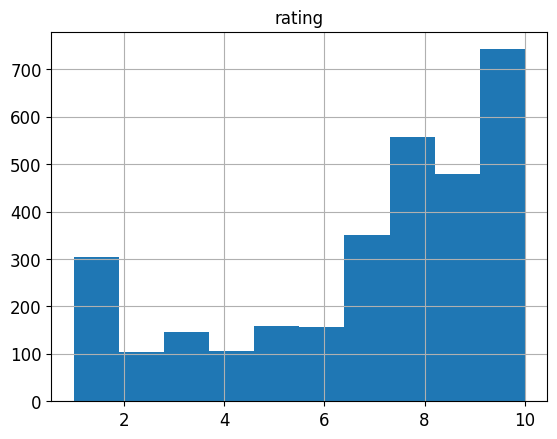

In [13]:
df[features_num].hist()

In [14]:
X_cat = pd.get_dummies(X[["sideEffects", "effectiveness"]], drop_first=True)

In [15]:
X_final = pd.concat([X[["rating"]], X_cat], axis=1)

In [16]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_final)


### Ejercicio 5: Otención de K, aproximación visual

Analiza la relación entre features (con scatter plots) una vez transformadas para comprobar si existe visualmente algún indicio del número de clústeres que podríamos estar buscando. Por otro lado este análisis nos puede hacer descartar alguna feature o generar una nueva

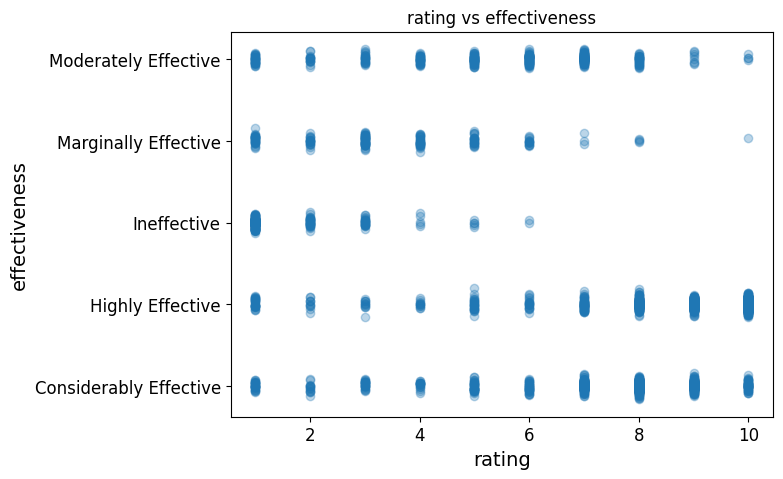

In [17]:
import numpy as np
import matplotlib.pyplot as plt

# Convertimos effectiveness a códigos para poder hacer scatter
eff_codes = X["effectiveness"].astype("category").cat.codes

plt.figure(figsize=(7,5))
plt.scatter(
    X["rating"],
    eff_codes + np.random.normal(0, 0.05, size=len(X)),  # jitter para que no se solapen
    alpha=0.3
)
plt.yticks(
    ticks=range(X["effectiveness"].nunique()),
    labels=X["effectiveness"].astype("category").cat.categories
)
plt.xlabel("rating")
plt.ylabel("effectiveness")
plt.title("rating vs effectiveness")
plt.show()


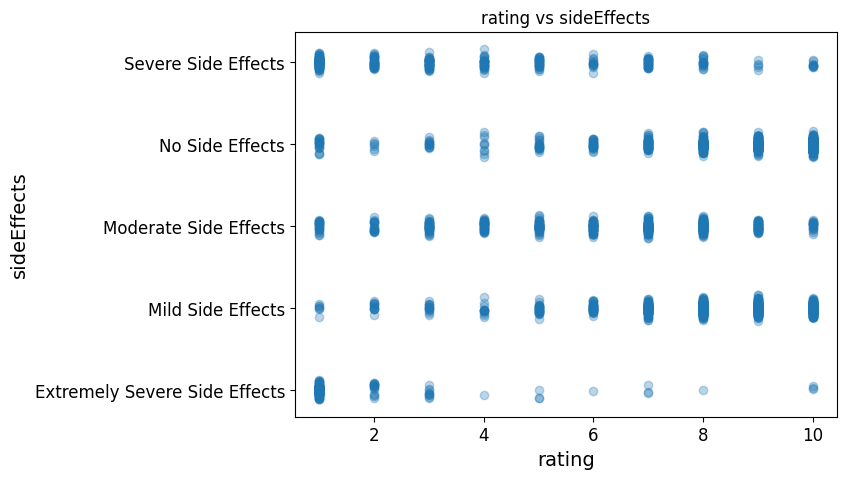

In [18]:
se_codes = X["sideEffects"].astype("category").cat.codes

plt.figure(figsize=(7,5))
plt.scatter(
    X["rating"],
    se_codes + np.random.normal(0, 0.05, size=len(X)),
    alpha=0.3
)
plt.yticks(
    ticks=range(X["sideEffects"].nunique()),
    labels=X["sideEffects"].astype("category").cat.categories
)
plt.xlabel("rating")
plt.ylabel("sideEffects")
plt.title("rating vs sideEffects")
plt.show()


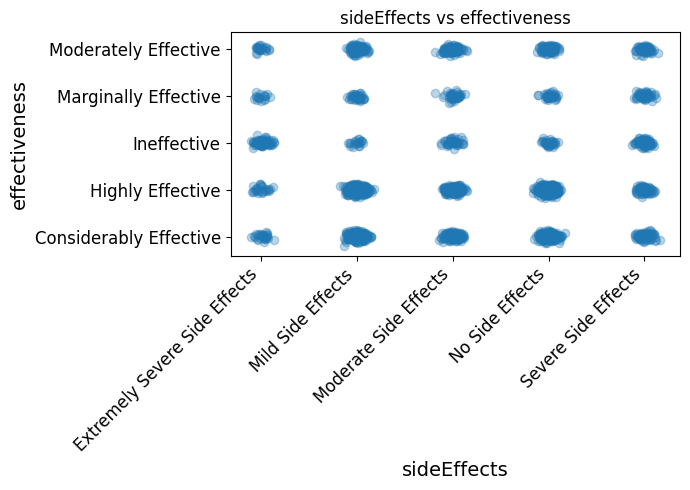

In [19]:
plt.figure(figsize=(7,5))
plt.scatter(
    se_codes + np.random.normal(0, 0.05, size=len(X)),
    eff_codes + np.random.normal(0, 0.05, size=len(X)),
    alpha=0.3
)

plt.xticks(
    ticks=range(X["sideEffects"].nunique()),
    labels=X["sideEffects"].astype("category").cat.categories,
    rotation=45,
    ha="right"
)

plt.yticks(
    ticks=range(X["effectiveness"].nunique()),
    labels=X["effectiveness"].astype("category").cat.categories
)

plt.xlabel("sideEffects")
plt.ylabel("effectiveness")
plt.title("sideEffects vs effectiveness")
plt.tight_layout()
plt.show()


### Ejercicio 6: Obtención de K, método del codo

Evalua diferentes valores K y escoge uno a partir del método del codo/elbow de inercia.

In [20]:
from sklearn.cluster import KMeans

kmeans_per_k = [KMeans(n_clusters=k, random_state= 42, n_init = 25).fit(X_scaled)
                for k in range(1, 10)]
inertias = [model.inertia_ for model in kmeans_per_k]

In [21]:
inertias

[27962.999999999993,
 22215.851594108663,
 17998.07183882856,
 14205.775199232798,
 11320.295845240384,
 8869.93668770714,
 6893.368545331984,
 6154.451154244227,
 5335.512162115419]

In [22]:
from kneed import KneeLocator

ks = range(1, 10)

knee = KneeLocator(
    ks, inertias,
    curve="convex",
    direction="decreasing"
)

elbow_k = knee.elbow

print("Elbow detectado:", knee.elbow)

Elbow detectado: 5


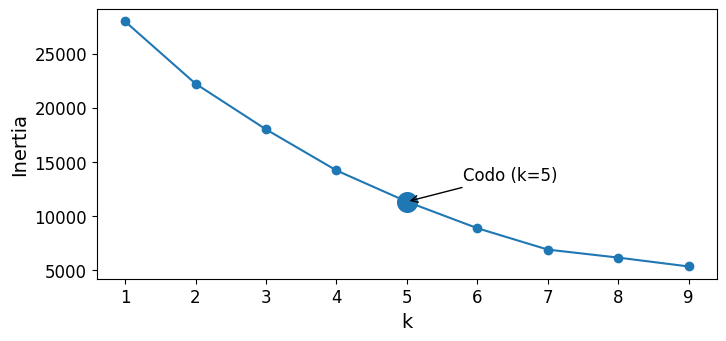

In [25]:
plt.figure(figsize=(8, 3.5))
plt.plot(ks, inertias, "o-")
plt.xlabel("k", fontsize=14)
plt.ylabel("Inertia", fontsize=14)

if elbow_k is not None:
    elbow_inertia = inertias[elbow_k - 1]

    plt.scatter(elbow_k, elbow_inertia, s=200)

    plt.annotate(
        f"Codo (k={elbow_k})",
        xy=(elbow_k, elbow_inertia),
        xytext=(elbow_k + 0.8, elbow_inertia + 2000),
        arrowprops=dict(arrowstyle="->"),
        fontsize=12
    )

plt.show()

### Ejercicio 7: Obtención de K, Score de Silueta

Comprueba el ajuste de k obteniendo el k que maximiza el score de silueta y pinta un gráfico de la evolución de dicho score con k. Usa los valores de k que hayas probado en el ejercicio anterior.

In [27]:
from sklearn.metrics import silhouette_score

silhouette_scores = [silhouette_score(X_scaled, model.labels_)
                     for model in kmeans_per_k[1:]]
silhouette_scores

[0.28594048550497997,
 0.3527776985125507,
 0.42871791566247835,
 0.47200616050264527,
 0.5118143913477765,
 0.5523285021175,
 0.5757450452204115,
 0.6069129635605466]

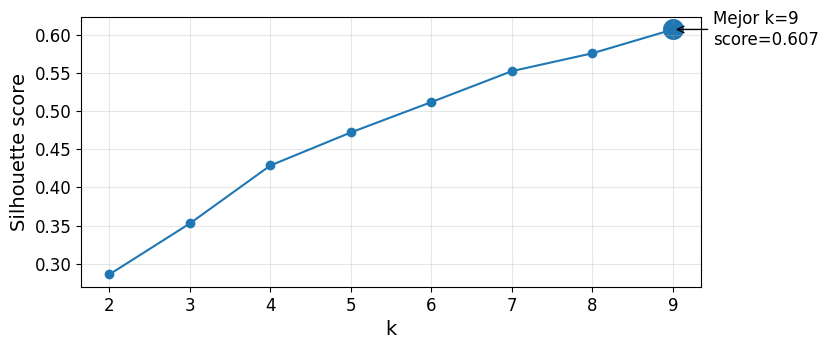

In [30]:
import numpy as np
import matplotlib.pyplot as plt

ks = list(range(2, 10))
best_k = ks[np.argmax(silhouette_scores)]
best_score = max(silhouette_scores)

plt.figure(figsize=(8, 3.5))
plt.plot(ks, silhouette_scores, "o-")
plt.xlabel("k", fontsize=14)
plt.ylabel("Silhouette score", fontsize=14)

# marcar mejor k
plt.scatter(best_k, best_score, s=200)

plt.annotate(
    f"Mejor k={best_k}\nscore={best_score:.3f}",
    xy=(best_k, best_score),
    xytext=(best_k + 0.5, best_score - 0.02),
    arrowprops=dict(arrowstyle="->"),
    fontsize=12
)

plt.xticks(ks)
plt.grid(True, alpha=0.3)
plt.show()


### Ejercicio 8: Obtención de K, diagrama de silueta

Para completar el estudio de k, muestra el diagramde silueta para k=2,3,4,5 y decide con este datos y los anteriores el valor de k a probar. NOTA: En la realidad, podríamos probar perfectamente k=2 y k=3 y luego que "Negocio" decidiera cuál le es más útil, aquí lo completamos por practicar todo lo aprendido

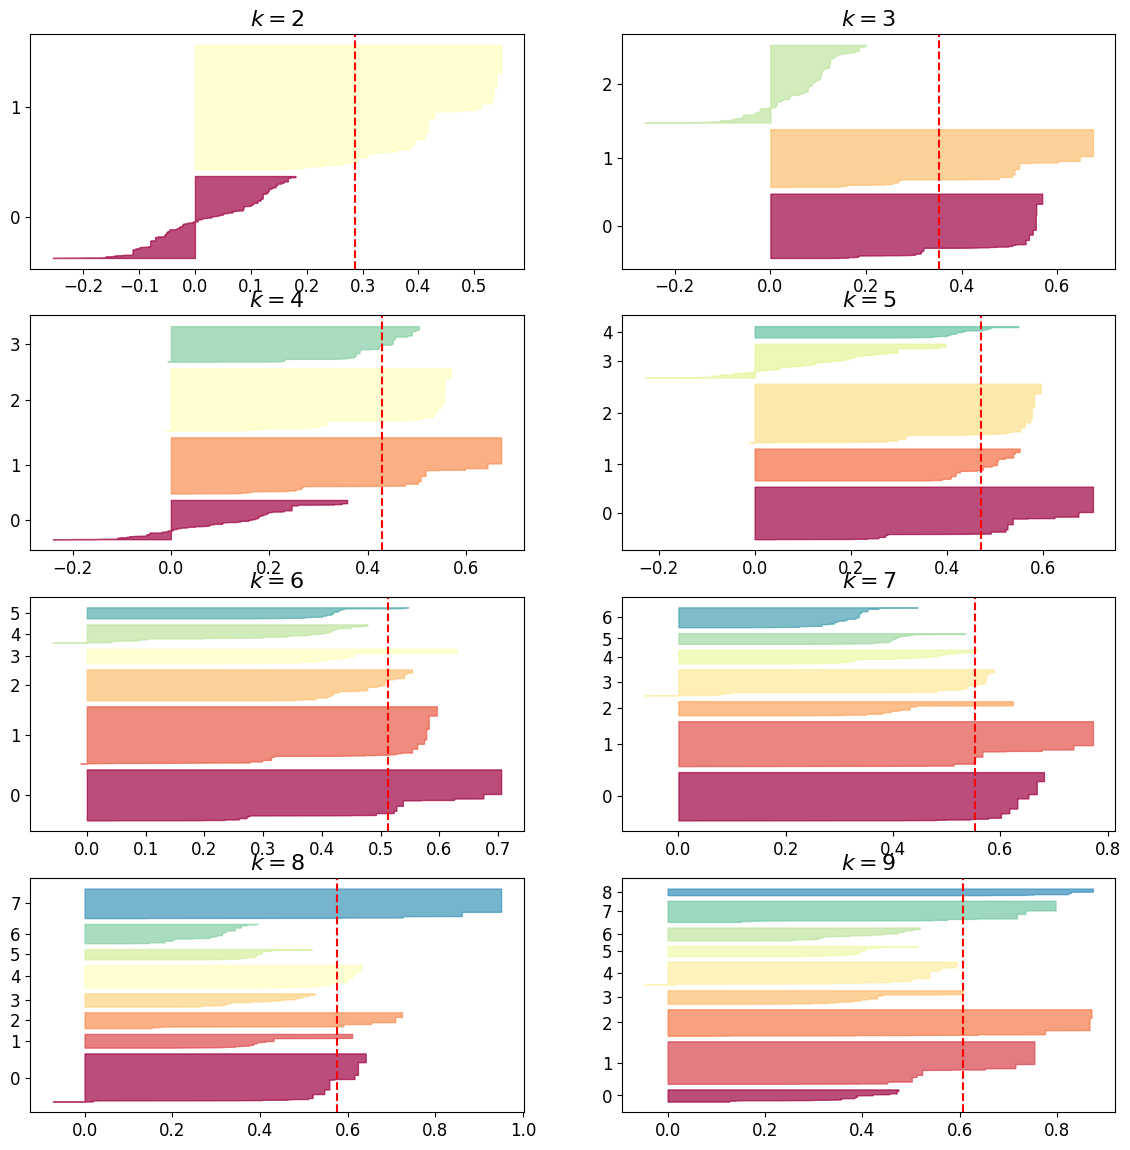

In [36]:
from sklearn.metrics import silhouette_samples
from matplotlib.ticker import FixedLocator, FixedFormatter

'''
La anchura de cada cuchillo representa el numero de muestras por cluster. Están ordenadas
por su coeficiente de silhouette, por eso tiene esa forma de cuchillo. Cuanta más caida tenga
indica que las muestras tienen un coeficiente mas disperso en ese cluster
Deberian estar todos los clusters por encima de la media.
Hay algunas lineas hacia la izda xq es el coeficiente negativo. Puntos asignados al cluster erroneo.
'''
plt.figure(figsize=(14, 14))

ks_to_try = range(2, 10)

for idx, k in enumerate(ks_to_try, start=1):
    plt.subplot(4, 2, idx)
    
    y_pred = kmeans_per_k[k - 1].labels_
    silhouette_coefficients = silhouette_samples(X_scaled, y_pred)

    padding = len(X_scaled) // 30
    pos = padding
    ticks = []
    for i in range(k):
        coeffs = silhouette_coefficients[y_pred == i]
        coeffs.sort()

        color = mpl.cm.Spectral(i / k)
        plt.fill_betweenx(np.arange(pos, pos + len(coeffs)), 0, coeffs,
                          facecolor=color, edgecolor=color, alpha=0.7)
        ticks.append(pos + len(coeffs) // 2)
        pos += len(coeffs) + padding

    plt.gca().yaxis.set_major_locator(FixedLocator(ticks))
    plt.gca().yaxis.set_major_formatter(FixedFormatter(range(k)))


    plt.axvline(x=silhouette_scores[k - 2], color="red", linestyle="--")
    plt.title("$k={}$".format(k), fontsize=16)


plt.show()

### Ejercico 9:

En general, una diferencia entre el proceso de construcción de un modelo no supervisado y un supervisado es que el ajuste de algunos hiperparámetros (como el número de clústeres) es anterior a la construcción del modelo. Por eso, construye un K-means para el valor (o valores) de K escogidos.

In [39]:
kmeans4 = KMeans(n_clusters=4, random_state=42, n_init=25).fit(X_scaled)
kmeans5 = KMeans(n_clusters=5, random_state=42, n_init=25).fit(X_scaled)

### Ejercicio 10

Vamos a comprobar resultados, analizando los valores medios y distribución de cada uno de los clústeres para el k óptimo. Si tuvieras más de un posible valor de k a probar, analiza aquí el de mayor score de silueta. Y utiliza el siguiente ejercicio para el otro. Además de hacer un describe de las features por clúster, pinta estos con un pairplot considerando sideEffects y rating como x e y (o viceversa) y el clúster como hue (color). Compara el resultado con los clústeres sugeridos en el ejercicio 5.

In [40]:
# Clusters predichos
clusters = kmeans4.labels_

# Dataset interpretativo (sin escalar)
df_clusters = X.copy()
df_clusters["cluster"] = clusters

df_clusters.head()


,rating,sideEffects,effectiveness,cluster
0,4,Mild Side Effects,Highly Effective,2
1,1,Severe Side Effects,Highly Effective,0
2,10,No Side Effects,Highly Effective,1
3,3,Mild Side Effects,Marginally Effective,2
4,2,Severe Side Effects,Marginally Effective,0


In [41]:
df_clusters.groupby("cluster").mean(numeric_only=True)


,rating
cluster,
0,2.731746
1,8.876804
2,8.257711
3,6.567426


In [42]:
df_clusters.groupby("cluster").describe()


rating                                                
          count      mean       std  min  25%   50%   75%   max
cluster                                                        
0         630.0  2.731746  2.275768  1.0  1.0   2.0   4.0  10.0
1         901.0  8.876804  1.594896  1.0  8.0  10.0  10.0  10.0
2        1005.0  8.257711  1.608076  1.0  8.0   8.0   9.0  10.0
3         571.0  6.567426  2.014053  1.0  5.0   7.0   8.0  10.0

In [43]:
pd.crosstab(df_clusters["cluster"], df_clusters["sideEffects"], normalize="index")


sideEffects,Extremely Severe Side Effects,Mild Side Effects,Moderate Side Effects,No Side Effects,Severe Side Effects
cluster,,,,,
0,0.261905,0.031746,0.069841,0.050794,0.585714
1,0.003330,0.000000,0.000000,0.996670,0.000000
2,0.005970,0.994030,0.000000,0.000000,0.000000
3,0.001751,0.000000,0.998249,0.000000,0.000000


In [44]:
pd.crosstab(df_clusters["cluster"], df_clusters["effectiveness"], normalize="index")


effectiveness,Considerably Effective,Highly Effective,Ineffective,Marginally Effective,Moderately Effective
cluster,,,,,
0,0.177778,0.169841,0.388889,0.117460,0.146032
1,0.283019,0.590455,0.000000,0.036626,0.089900
2,0.362189,0.482587,0.000000,0.036816,0.118408
3,0.345009,0.360771,0.003503,0.075306,0.215412


In [45]:
import seaborn as sns
import matplotlib.pyplot as plt

plot_df = df_clusters.copy()

plot_df["sideEffects_code"] = plot_df["sideEffects"].astype("category").cat.codes
plot_df["effectiveness_code"] = plot_df["effectiveness"].astype("category").cat.codes


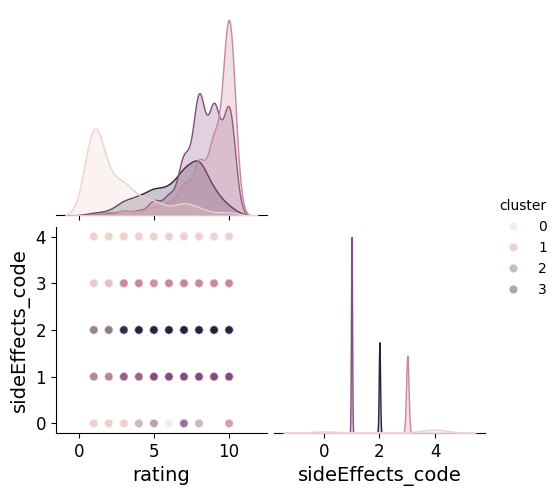

In [46]:
sns.pairplot(
    plot_df,
    vars=["rating", "sideEffects_code"],
    hue="cluster",
    corner=True,
    plot_kws={"alpha": 0.4}
)
plt.show()


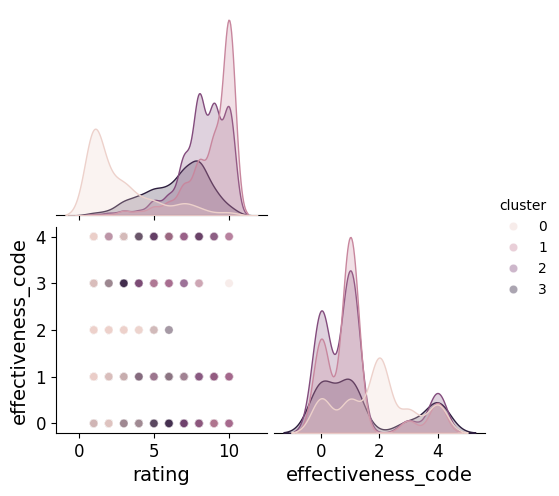

In [47]:
sns.pairplot(
    plot_df,
    vars=["rating", "effectiveness_code"],
    hue="cluster",
    corner=True,
    plot_kws={"alpha": 0.4}
)
plt.show()


### Ejercicio 11, EXTRA: Más valores de K

Repite el análisis del ejercicio 10 para un K diferente pero que consideres que tiene sentido aplicar.

## Interpretación de resultados (K-Means)

Tras seleccionar las variables más útiles para el clustering (descartando las columnas de texto por su altísima cardinalidad), se trabajó finalmente con tres features: **rating** (numérica), **sideEffects** (categórica) y **effectiveness** (categórica).  

Dado que K-Means necesita variables numéricas, las categóricas se transformaron a valores numéricos (codificación) y posteriormente se aplicó **escalado** para que todas las variables tuvieran un peso comparable en el cálculo de distancias.

---

### Selección del número óptimo de clústeres

Para elegir el número óptimo de clústeres se utilizaron dos enfoques:

- **Método del codo (inercia)**: sugirió un valor de k moderado (en torno a 4), ya que a partir de ese punto la mejora en la inercia disminuye.
- **Silhouette score**: mostró una mejora progresiva al aumentar k, alcanzando valores más altos en k grandes (como 9). Sin embargo, en la práctica un k muy alto puede generar clusters demasiado fragmentados y menos útiles desde el punto de vista interpretativo.

Finalmente se analizó un modelo con un k moderado (por ejemplo, **k = 4**), ya que permite un equilibrio razonable entre **calidad del agrupamiento** e **interpretabilidad**.

---

## Análisis de los clústeres obtenidos

Para interpretar los clusters se analizaron:

- La media y distribución del **rating** por clúster.
- La distribución de categorías de **sideEffects** por clúster (mediante tablas normalizadas).
- La distribución de categorías de **effectiveness** por clúster (mediante tablas normalizadas).
- Una visualización tipo **pairplot** usando `rating` y los códigos numéricos de las variables categóricas, coloreando por clúster.

Los resultados muestran que los clústeres separan claramente perfiles de experiencia del paciente. En particular, se observa que:

- Existe un clúster asociado a **ratings bajos**, con mayor proporción de **efectos secundarios severos** y con peor percepción de efectividad.
- Otros clústeres agrupan experiencias con **ratings altos**, diferenciándose principalmente por el nivel de efectos secundarios (por ejemplo, “No Side Effects”, “Mild Side Effects”, “Moderate Side Effects”).
- En general, los clústeres con mejores ratings tienden también a presentar mayor proporción de valoraciones como **Highly Effective** o **Considerably Effective**.

---

## Conclusión

El clustering permite segmentar los medicamentos en grupos coherentes que representan perfiles distintos de experiencia del usuario: desde experiencias negativas (baja puntuación y efectos secundarios severos) hasta experiencias positivas (alta puntuación con distintos niveles de efectos secundarios).  

Aunque el silhouette score aumenta con k, valores moderados como **k = 4** o **k = 5** resultan más interpretables y útiles, ya que generan clústeres más estables y fáciles de explicar.
